In [1]:
import pandas as pd

#### Nutze ";" als Trennzeichen: 
data_a = pd.read_csv('churn_part_a.csv', delimiter = ';')

In [2]:
data_a = pd.read_csv('churn_part_a.csv')

In [3]:
data_a.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0


In [4]:
data_b = pd.read_csv('churn_part_b.csv')

In [5]:
data_b.head()

,CustomerId,Geography,Gender,Age
0,15634602,France,Female,42.0
1,15647311,Spain,Female,NaN
2,15619304,France,Female,42.0
3,15701354,France,Female,39.0
4,15737888,Spain,Female,43.0


### Combine Datasets
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.merge.html

In [6]:
data = pd.merge(data_a, data_b, how='inner', on='CustomerId')

In [7]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0
1,2,15647311,Hill,608,1,83807.86,1,0,1,112542.58,0,Spain,Female,NaN
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0


In [8]:
data.shape

(10000, 14)

In [9]:
data_a.shape

(10000, 11)

In [10]:
data_b.shape

(10000, 4)

### %-Anteil der Kunden die uns verlassen haben

In [11]:
data["Exited"].sum()/data.shape[0]

np.float64(0.2037)

### Ermittle Anzahl vollständiger Datensätze

In [12]:
data.dropna(axis=0).shape

(9996, 14)

### "Entferne"  Zeilen, in denen entweder Gender oder Age oder Beides NaN ist

In [13]:
data.dropna(axis=0, subset=['Gender', 'Age']).shape

(9997, 14)

In [14]:
data.shape

(10000, 14)

In [15]:
### Erstelle Datensatz in dem die Zeilen mit NaNs entfernt wurden

In [16]:
data_cleaned = data.dropna(axis=0)

In [17]:
data_cleaned.shape

(9996, 14)

### Visuelle Analyse

In [18]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


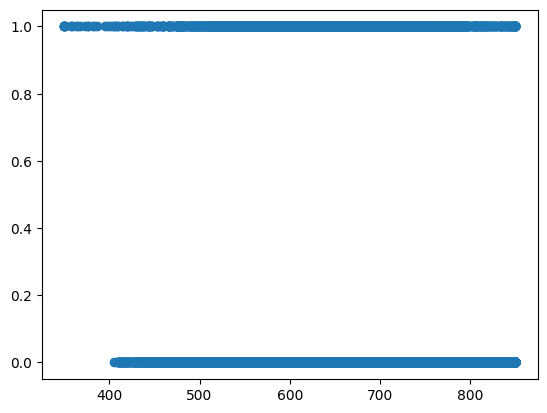

In [19]:
plt.scatter(data_cleaned['CreditScore'], data_cleaned['Exited'])

In [20]:
data_cleaned.groupby('Exited')['CreditScore'].mean()

Exited
0    651.844598
1    645.347741
Name: CreditScore, dtype: float64

In [21]:
data_cleaned.groupby('Exited')['Age'].mean()

Exited
0    37.410427
1    44.831532
Name: Age, dtype: float64

In [22]:
data_cleaned.groupby('Exited')['Age'].min()

Exited
0    18.0
1    18.0
Name: Age, dtype: float64

### 0. Vorhersagemodel: Logistische Regression (statsmodels)

In [23]:
import statsmodels.api as sm

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
x = data_cleaned[['Age', 'CreditScore', 'Balance']]

In [ ]:
x = sm.add_constant(x)

In [ ]:
y = data_cleaned['Exited']

In [ ]:
log_reg_statsmodels = sm.Logit(y, x).fit()

Optimization terminated successfully.
         Current function value: 0.460265
         Iterations 6


In [ ]:
log_reg_statsmodels.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Exited   No. Observations:                 9996
Model:                          Logit   Df Residuals:                     9992
Method:                           MLE   Df Model:                            3
Date:                Tue, 10 Oct 2023   Pseudo R-squ.:                 0.08942
Time:                        18:13:58   Log-Likelihood:                -4600.8
converged:                       True   LL-Null:                       -5052.6
Covariance Type:            nonrobust   LLR p-value:                1.453e-195
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.8579      0.206    -18.724      0.000      -4.262      -3.454
Age             0.0633      0.002     26.552      0.000       0.059       0.068
CreditScore    -0.0008      0.000     -2.857      0.004      -0.001      -0.000
Balance      5.027e-06   4.33e-07     11.603      0.000    4.18e-06    5.88e-06
===============================================================================
"""

### Interpretation of coefficients
coefficient of age means that if age increase by one the likelihoof of churning increases by 6.33%-points

In [ ]:
predictions = log_reg_statsmodels.predict(x)

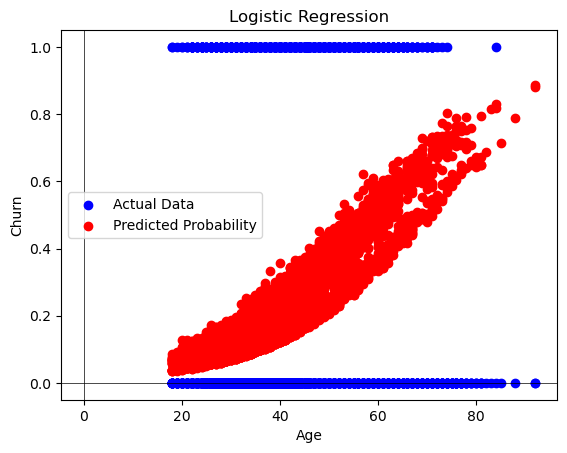

In [ ]:
plt.scatter(x['Age'], y, color='blue', label='Actual Data')
plt.scatter(x['Age'], predictions, color='red', label='Predicted Probability')
plt.xlabel('Age')
plt.ylabel('Churn')
plt.title('Logistic Regression')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.show()

### 1. Vorhersagemodel: Logistische Regression (sklearn)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

### Selektiere Features (Variablen die für die Vorhersage genutzt werden)

In [ ]:
x = data_cleaned[['Age', 'CreditScore', 'Balance']]

In [ ]:
random_variable = 1234

In [ ]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [ ]:
log_reg_simple.fit(x, data_cleaned['Exited'])

LogisticRegression(random_state=1234)

In [ ]:
log_reg_simple.coef_

array([[ 4.27738033e-02, -5.18560694e-03,  3.55696987e-06]])

### Zeige Koeffizienten formatiert an

In [ ]:
import numpy as np

In [ ]:
coefficients_formated =  pd.concat(
    [
     pd.Series(['Age', 'CreditScore', 'Balance']),
     pd.DataFrame(np.transpose(log_reg_simple.coef_))
    ],
     axis=1
 )

In [ ]:
coefficients_formated

,0,0
0,Age,0.042774
1,CreditScore,-0.005186
2,Balance,0.000004


### Berechne Wahrscheinlichkeit dass uns ein Kunden verlässt (Exited = 1)

In [ ]:
log_reg_simple.predict_proba(x)

array([[0.80433085, 0.19566915],
       [0.55945754, 0.44054246],
       [0.87618139, 0.12381861],
       ...,
       [0.89444138, 0.10555862],
       [0.87434585, 0.12565415],
       [0.92031354, 0.07968646]])

jeder Kunde erhählt eine Wahrscheinlichkeit dass er bei uns bleibt (Exited=0) und eine dass er uns verlässt (Exited=1)

### Vorhersage ob Kunden uns verlässt (1) oder bei uns bleibt (0), jede Zahl repräsentiert einen Kunden


In [ ]:
log_reg_simple.predict(x)

array([0, 0, 0, ..., 0, 0, 0])

### Berechnung Confusion Matrix

In [ ]:
predictions = log_reg_simple.predict(x)

confusion_matrix(beboachtete Werte, vorhergesagte Werte, Sortierung)

In [ ]:
cnf_matrix = metrics.confusion_matrix(
    predictions, 
    data_cleaned['Exited'],                     
    labels = [True, False]
)

In [ ]:
cnf_matrix

array([[ 113, 1923],
       [ 181, 7779]])

In [ ]:
accuracy = (113 + 7779)/(113 + 1923 + 181 + 7779)

In [ ]:
accuracy

0.789515806322529

In [ ]:
precision = 113/(113 + 181)

In [ ]:
precision

0.3843537414965986

### Model with more variables

In [ ]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0


In [ ]:
x = data_cleaned[['Age', 'CreditScore', 'Balance', 'EstimatedSalary']]

In [ ]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [ ]:
log_reg_simple.fit(x, data_cleaned['Exited'])

LogisticRegression(random_state=1234)

In [ ]:
log_reg_simple.coef_

array([[ 4.34627882e-02, -5.03045238e-03,  3.62329569e-06,
        -1.34978002e-06]])

In [ ]:
predictions = log_reg_simple.predict(x)

In [ ]:
cnf_matrix = metrics.confusion_matrix(
                    data_cleaned['Exited'], 
                    predictions, 
                    labels = [True, False]
                )

In [ ]:
cnf_matrix

array([[ 112, 1924],
       [ 176, 7784]])

In [ ]:
112/(112+ 176)

0.3888888888888889

### Berechnung Accuracy mit implementierter Lösung

In [ ]:
metrics.accuracy_score(data_cleaned['Exited'], 
                    predictions)

0.7899159663865546

### Berechnung Precision mit implementierter Lösung

In [ ]:
metrics.precision_score(data_cleaned['Exited'], 
                    predictions)

0.3888888888888889

### Erzeugen von Spalte die den Wert True bei Frauen animmt und False bei Männern

In [ ]:
data_cleaned['Gender_Boolean'] = data['Gender'] == 'Female'

/var/folders/pl/vn_7858x74v4m_qxwq3tykp40000gn/T/ipykernel_4977/2184254904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Gender_Boolean'] = data['Gender'] == 'Female'


In [ ]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False


### Umwandeln in Zahl

In [ ]:
data_cleaned['Gender_numeric'] = data_cleaned['Gender_Boolean'].astype(int)

/var/folders/pl/vn_7858x74v4m_qxwq3tykp40000gn/T/ipykernel_4977/1977041434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Gender_numeric'] = data_cleaned['Gender_Boolean'].astype(int)


In [ ]:
data_cleaned.head()

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean,Gender_numeric
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True,1
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True,1
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True,1
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True,1
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False,0


In [ ]:
data_cleaned['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

### Generierung Dummy Encoding für die Spalte Geography

In [ ]:
geography_dummies = pd.get_dummies(data_cleaned['Geography'], prefix="g")

In [ ]:
geography_dummies

,g_France,g_Germany,g_Spain
0,1,0,0
2,1,0,0
3,1,0,0
4,0,0,1
5,0,0,1
...,...,...,...
9995,1,0,0
9996,1,0,0
9997,1,0,0
9998,0,1,0


### Mergen von data_cleaned und geography_dummies (Spalten zu data_cleaned hinzfügen)

In [ ]:
data_full = pd.concat([data_cleaned, geography_dummies], axis=1)

In [ ]:
data_full

,RowNumber,CustomerId,Surname,CreditScore,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography,Gender,Age,Gender_Boolean,Gender_numeric,g_France,g_Germany,g_Spain
0,1,15634602,Hargrave,619,2,0.00,1,1,1,101348.88,1,France,Female,42.0,True,1,1,0,0
2,3,15619304,Onio,502,8,159660.80,3,1,0,113931.57,1,France,Female,42.0,True,1,1,0,0
3,4,15701354,Boni,699,1,0.00,2,0,0,93826.63,0,France,Female,39.0,True,1,1,0,0
4,5,15737888,Mitchell,850,2,125510.82,1,1,1,79084.10,0,Spain,Female,43.0,True,1,0,0,1
5,6,15574012,Chu,645,8,113755.78,2,1,0,149756.71,1,Spain,Male,44.0,False,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,5,0.00,2,1,0,96270.64,0,France,Male,39.0,False,0,1,0,0
9996,9997,15569892,Johnstone,516,10,57369.61,1,1,1,101699.77,0,France,Male,35.0,False,0,1,0,0
9997,9998,15584532,Liu,709,7,0.00,1,0,1,42085.58,1,France,Female,36.0,True,1,1,0,0
9998,9999,15682355,Sabbatini,772,3,75075.31,2,1,0,92888.52,1,Germany,Male,42.0,False,0,0,1,0


### Neues Modell mit Herkunftsland und Geschlecht

In [ ]:
x_full = data_full[['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Gender_numeric',
                 'g_Spain', 'g_Germany']]

In [ ]:
log_reg_simple = LogisticRegression(random_state=random_variable)

In [ ]:
log_reg_simple.fit(x_full, data_full['Exited'])

LogisticRegression(random_state=1234)

In [ ]:
predictions_full = log_reg_simple.predict(x_full)

In [ ]:
cnf_matrix = metrics.confusion_matrix(
                    data_full['Exited'], 
                    predictions_full, 
                    labels = [True, False]
                )

In [ ]:
cnf_matrix

array([[ 113, 1923],
       [ 178, 7782]])

In [ ]:
metrics.accuracy_score(data_full['Exited'], 
                    predictions_full)

0.7898159263705482

In [ ]:
metrics.precision_score(data_full['Exited'], 
                    predictions_full)

0.38831615120274915

In [ ]:
coefficients_formated =  pd.concat(
    [
     pd.Series(['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Gender_numeric',
                 'g_Spain', 'g_Germany']),
     pd.DataFrame(np.transpose(log_reg_simple.coef_))
    ],
     axis=1
 )

In [ ]:
coefficients_formated

,0,0
0,Age,0.043496
1,CreditScore,-0.005033
2,Balance,0.000004
3,EstimatedSalary,-0.000001
4,Gender_numeric,0.000843
5,g_Spain,-0.000332
6,g_Germany,0.000942
